## 1. Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score, 
                            precision_score, recall_score, f1_score)

import os
import joblib
import warnings
warnings.filterwarnings('ignore')


## 2. Data Loading

In [2]:
# Load the dataset
df = pd.read_csv(r'C:\Users\prave\OneDrive\Desktop\customer-churn-intelligence\data\churn.csv')

print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
print(f"Column names: {df.columns.tolist()}")
df.head()

Number of rows: 7043, Number of columns: 21
Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data types overview
print("Data Types:")
print(df.dtypes.to_string())


Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object


In [4]:
# check for missing values and duplicates
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [5]:
# convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# check for missing values again after conversion
print("Missing values after conversion:")   
print(f"Nan in TotalCharges: {df['TotalCharges'].isnull().sum()}")

print("Those are likely due to the fact that 'TotalCharges' is empty for customers with no tenure, so we can fill those NaN values with 0.")
df['TotalCharges'].fillna(0, inplace=True)

print(f"remaining missing values in dataset: {df.isnull().sum().sum()}")

# Drop 'customerID' as it is not useful for analysis
df.drop('customerID', axis=1, inplace=True)

# Encode Target Variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# new df shape
print(f"New dataset shape: {df.shape}")
df.head()


Missing values after conversion:
Nan in TotalCharges: 11
Those are likely due to the fact that 'TotalCharges' is empty for customers with no tenure, so we can fill those NaN values with 0.
remaining missing values in dataset: 0
New dataset shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [6]:
print("0 means Not Churned, 1 means Churned. \nChurned means the customer has left the company, while Not Churned means the customer is still with the company.")

df['Churn'].value_counts()
print(f"Churn distribution:\n{df['Churn'].value_counts()}")

ratio = df['Churn'].value_counts()[1] / df['Churn'].value_counts()[0]
print(f"Churn ratio (Churned/Not Churned): {ratio:.2f}")

0 means Not Churned, 1 means Churned. 
Churned means the customer has left the company, while Not Churned means the customer is still with the company.
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn ratio (Churned/Not Churned): 0.36


In [7]:
# show me rows where total charges is 0
print("Rows where TotalCharges is 0:")
print(df[df['TotalCharges'] == 0][['tenure', 'TotalCharges', 'Churn']])

Rows where TotalCharges is 0:
      tenure  TotalCharges  Churn
488        0           0.0      0
753        0           0.0      0
936        0           0.0      0
1082       0           0.0      0
1340       0           0.0      0
3331       0           0.0      0
3826       0           0.0      0
4380       0           0.0      0
5218       0           0.0      0
6670       0           0.0      0
6754       0           0.0      0


## 3. Business KPIs

Before any modelling, we calculate the headline numbers a stakeholder would see on a dashboard.


In [8]:

total_customers = df.shape[0]
print(f"Total Customers: {total_customers}")

churned_customers = df['Churn'].sum()
print(f"Churned Customers: {churned_customers}")

churn_rate = (churned_customers / total_customers) * 100
print(f"\nChurn Rate: {churn_rate:.2f}%")

average_monthly_charges = df['MonthlyCharges'].mean()
print(f"\nAverage Monthly Charges: ${average_monthly_charges:.2f}")

average_total_charges = df['TotalCharges'].mean()
print(f"Average Total Charges: ${average_total_charges:.2f}")

average_tenure_churned = df[df['Churn'] == 1]['tenure'].mean()
print(f"Average Tenure Churned: {average_tenure_churned:.2f} months")

average_tenure_retained = df[df['Churn'] == 0]['tenure'].mean()
print(f"Average Tenure Retained: {average_tenure_retained:.2f} months")

revenue_lost = df[df['Churn'] == 1]['MonthlyCharges'].sum()
print(f"\nTotal Revenue Lost from Churned Customers: ${revenue_lost:,.2f}")

churn_per_contract = df.groupby('Contract')['Churn'].mean().reset_index()
print("\nChurn Rate by Contract Type:")
print(churn_per_contract)

print("\nKey Insights:")
print(f"• Approximately one in four customers are leaving the company")
print(f"• On average, churned customers stayed for {average_tenure_churned:.2f} months before leaving")
print(f"• On average, loyal customers stayed for {average_tenure_retained:.2f} months")
print(f"• The company is losing ${revenue_lost:,.2f} in monthly revenue from churned customers")
print(f"• month-to-month contracts have the highest churn rate ({churn_per_contract[churn_per_contract['Contract'] == 'Month-to-month']['Churn'].iloc[0]:.2f}%), followed by one-year and two-year contracts")



Total Customers: 7043
Churned Customers: 1869

Churn Rate: 26.54%

Average Monthly Charges: $64.76
Average Total Charges: $2279.73
Average Tenure Churned: 17.98 months
Average Tenure Retained: 37.57 months

Total Revenue Lost from Churned Customers: $139,130.85

Churn Rate by Contract Type:
         Contract     Churn
0  Month-to-month  0.427097
1        One year  0.112695
2        Two year  0.028319

Key Insights:
• Approximately one in four customers are leaving the company
• On average, churned customers stayed for 17.98 months before leaving
• On average, loyal customers stayed for 37.57 months
• The company is losing $139,130.85 in monthly revenue from churned customers
• month-to-month contracts have the highest churn rate (0.43%), followed by one-year and two-year contracts


## 4. SQL Analytics

Same questions can be answered with SQL (as they often are in real analytics environments).


In [9]:
# Load the dataset into a SQLite database
conn = sqlite3.connect('customers.db')
df.to_sql('churn_data', conn, if_exists='replace', index=False)

print("Dataset loaded into SQLite database 'customers.db' with table name 'churn_data'.")
columns = df.columns.tolist()
print(f"Columns in the database: {columns}")

Dataset loaded into SQLite database 'customers.db' with table name 'churn_data'.
Columns in the database: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [10]:
# Helper Functions for SQL Queries
# Use this function to execute SQL queries on the 'customers.db' database and return results as a DataFrame

def execute_query(query):
    with conn:
        return pd.read_sql_query(query, conn)


In [11]:
# Q1. Overall Churn Distribution
query_churn_distribution = ("""
SELECT Churn, COUNT(*) AS Count, ROUND((COUNT(*) * 100.0) / (SELECT COUNT(*) FROM churn_data), 2) AS Percentage
FROM churn_data
GROUP BY Churn
""")
churn_distribution = execute_query(query_churn_distribution)
print("Churn Distribution:")
print(churn_distribution)

# Q2. Churn Rate by Contract Type
query_churn_by_contract = ("""
SELECT Contract, ROUND(AVG(Churn) * 100.0, 2) AS ChurnRate, COUNT(*) AS ChurnedCustomers
FROM churn_data
GROUP BY Contract
ORDER BY ChurnRate DESC
""")
churn_by_contract = execute_query(query_churn_by_contract)
print("\nChurn Rate by Contract Type:")
print(churn_by_contract)

# Q3. Revenue Lost from Churned Customers
query_revenue_lost = ("""
SELECT Contract, ROUND(SUM(MonthlyCharges), 2) AS TotalRevenueLost, COUNT(*) AS ChurnedCustomers
FROM churn_data
WHERE Churn = 1
GROUP BY Contract
""")
revenue_lost = execute_query(query_revenue_lost)
print("\nRevenue Lost from Churned Customers:")
print(revenue_lost)

# Q4. Payment Method and Churn
query_payment_churn = ("""
SELECT PaymentMethod, ROUND(AVG(Churn) * 100.0, 2) AS ChurnRate, COUNT(*) AS CustomerCount
FROM churn_data 
GROUP BY PaymentMethod
ORDER BY ChurnRate DESC
""")
payment_churn = execute_query(query_payment_churn)
print("\nChurn Rate by Payment Method:")
print(payment_churn)


# Q5. Tenure Segmentation
query_tenure_segmentation = ("""
SELECT 
    CASE 
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure > 12 AND tenure <= 24 THEN '13-24 months'
        WHEN tenure > 24 AND tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS TenureSegment,
    ROUND(AVG(Churn) * 100.0, 2) AS ChurnRate,
    COUNT(*) AS CustomerCount
FROM churn_data
GROUP BY TenureSegment
ORDER BY ChurnRate DESC
""")    
tenure_segmentation = execute_query(query_tenure_segmentation)
print("\nChurn Rate by Tenure Segmentation:")
print(tenure_segmentation)

Churn Distribution:
   Churn  Count  Percentage
0      0   5174       73.46
1      1   1869       26.54

Churn Rate by Contract Type:
         Contract  ChurnRate  ChurnedCustomers
0  Month-to-month      42.71              3875
1        One year      11.27              1473
2        Two year       2.83              1695

Revenue Lost from Churned Customers:
         Contract  TotalRevenueLost  ChurnedCustomers
0  Month-to-month         120847.10              1655
1        One year          14118.45               166
2        Two year           4165.30                48

Churn Rate by Payment Method:
               PaymentMethod  ChurnRate  CustomerCount
0           Electronic check      45.29           2365
1               Mailed check      19.11           1612
2  Bank transfer (automatic)      16.71           1544
3    Credit card (automatic)      15.24           1522

Churn Rate by Tenure Segmentation:
  TenureSegment  ChurnRate  CustomerCount
0   0-12 months      47.44           218

## 5. Exploratory Data Analysis

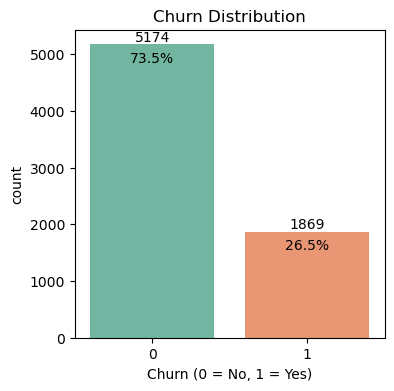

In [12]:
# 1. EDA of Churn Distribution

plt.figure(figsize=(4, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
ax = plt.gca()
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0,0.1), textcoords='offset points')

# percentage labels
total = len(df)
for p in ax.patches:
    percentage = (p.get_height() / total) * 100
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, -15), textcoords='offset points')



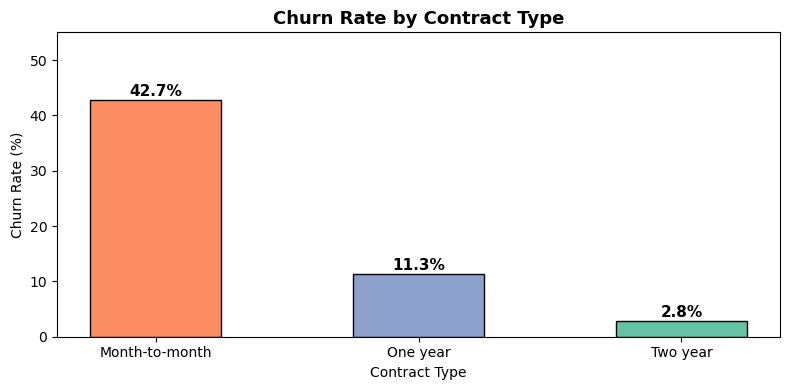

 Insight: Month-to-month customers churn at ~43% vs ~11% (1-year) and ~3% (2-year).
 Converting even 20% of M2M customers to annual plans will be significant.


In [13]:
# 2. Churn by Contract Type

contract_churn = df.groupby('Contract')['Churn'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=['#fc8d62', '#8da0cb', '#66c2a5'], edgecolor='black', width=0.5)
ax.set_title('Churn Rate by Contract Type', fontweight='bold', fontsize=13)
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Contract Type')
ax.set_ylim(0, 55)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print(" Insight: Month-to-month customers churn at ~43% vs ~11% (1-year) and ~3% (2-year).")
print(" Converting even 20% of M2M customers to annual plans will be significant.")



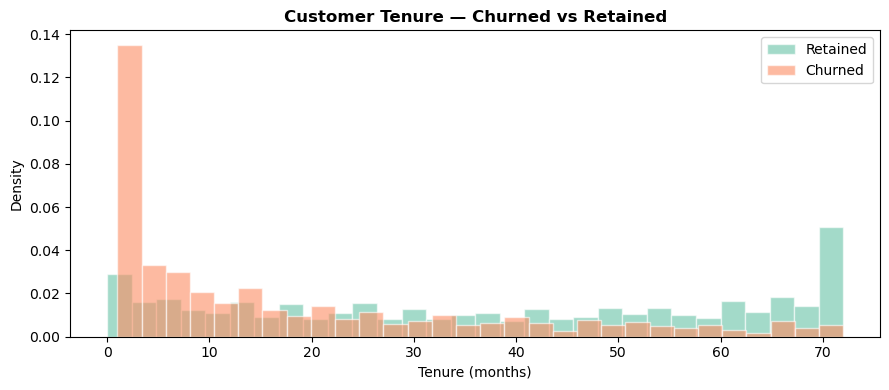

 Insight: Most churners leave within the first 12 months.
 The first year is the critical retention window — onboarding quality matters most.


In [14]:
# 3. Customer tenure distribution by churn
fig, ax = plt.subplots(figsize=(9, 4))
for label, color, name in [(0, '#66c2a5', 'Retained'), (1, '#fc8d62', 'Churned')]:
    ax.hist(df[df['Churn'] == label]['tenure'], bins=30,
            alpha=0.6, color=color, label=name, edgecolor='white', density=True)
ax.set_title('Customer Tenure — Churned vs Retained', fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print(" Insight: Most churners leave within the first 12 months.")
print(" The first year is the critical retention window — onboarding quality matters most.")

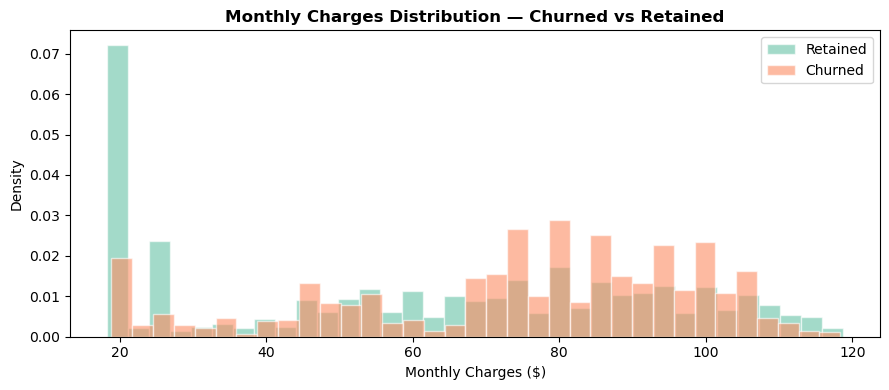

 Insight: Churned customers pay significantly higher monthly charges.
 High-value customers who feel they aren't getting value are most at risk.


In [15]:
# 4. Monthly Charges Distribution by Churn
fig, ax = plt.subplots(figsize=(9, 4))
for label, color, name in [(0, '#66c2a5', 'Retained'), (1, '#fc8d62', 'Churned')]:
    ax.hist(df[df['Churn'] == label]['MonthlyCharges'], bins=35,
            alpha=0.6, color=color, label=name, edgecolor='white', density=True)
ax.set_title('Monthly Charges Distribution — Churned vs Retained', fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print(" Insight: Churned customers pay significantly higher monthly charges.")
print(" High-value customers who feel they aren't getting value are most at risk.")

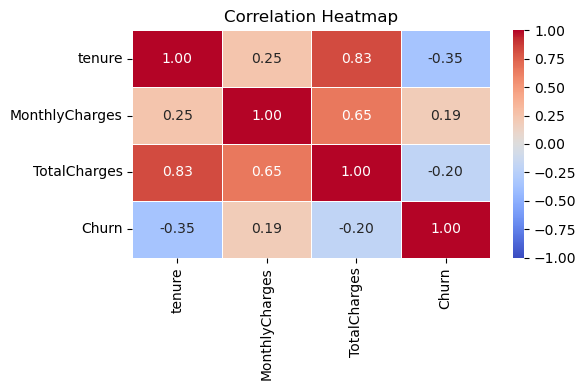

 Insight: Tenure has a strong negative correlation with churn (-0.35).
 The longer a customer stays, the less likely they are to churn.


In [16]:
# 5. Correlation Heat Map

num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].copy()
corr = num_df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print(" Insight: Tenure has a strong negative correlation with churn (-0.35).")
print(" The longer a customer stays, the less likely they are to churn.")



## 6. Data Preprocessing
1. **Label-encode** binary Yes/No columns
2. **One-hot encode** multi-category columns
3. **Train-test split** (80/20, stratified)
4. **Scale** numerical features for Logistic Regression


In [17]:
# Label-Encoding

df_model=df.copy()

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("Label encoding complete for binary categorical columns.")
df_model[binary_cols].head()



Label encoding complete for binary categorical columns.


,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1


In [18]:
# One-hot encode remaining categorical columns
ohe_cols = df_model.select_dtypes(include='object').columns.tolist()

df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=True)

print(f"One-hot encoded dataset shape: {df_model.shape}")
df_model.head()
print(df_model.columns)

One-hot encoded dataset shape: (7043, 31)
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [19]:
# Step 3: Define X and y 
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Step 4: Train-test split (stratified to preserve churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Step 5: Scaling (for Logistic Regression only) 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\nPreprocessing complete. Scaling applied (train only).")




Preprocessing complete. Scaling applied (train only).


## 7. Model Training

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),   
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state= 42),    
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42)
}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "ROC AUC": round(roc_auc_score(y_test, y_prob), 4)
    })
results_df = pd.DataFrame(results).sort_values(by="ROC AUC", ascending=False)
results_df

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004569 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8062,0.6573,0.5642,0.6072,0.8427
3,Gradient Boosting,0.7991,0.6564,0.5107,0.5744,0.8423
5,LightGBM,0.7942,0.6312,0.5401,0.5821,0.8362
2,Random Forest,0.7842,0.6207,0.4813,0.5422,0.8232
4,XGBoost,0.7722,0.5831,0.4973,0.5368,0.8224
1,Decision Tree,0.7317,0.4944,0.4759,0.4850,0.6495


### Since Logistic Regression has best ROC AUC value, consider it as best model

In [21]:
# Classification Report

best_model=models['Logistic Regression']
y_pred=best_model.predict(X_test)  
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn'])) 

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

   Non-Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 8. Confusuion Matrix 

In [24]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual No Churn', 'Actual Churn'],
    columns=['Predicted No Churn', 'Predicted Churn']
)
cm_df

,Predicted No Churn,Predicted Churn
Actual No Churn,925,110
Actual Churn,163,211


In [25]:
# Custom Threshold to improve recall for "CHURN"

y_prob = best_model.predict_proba(X_test)[:,1]
y_pred_custom=(y_prob >= 0.3).astype(int)
print("Classification Report for Custom Threshold (0.3) Random Forest:")
print(classification_report(y_test, y_pred_custom, target_names=['Non-Churn', 'Churn']))


Classification Report for Custom Threshold (0.3) Random Forest:
              precision    recall  f1-score   support

   Non-Churn       0.90      0.75      0.82      1035
       Churn       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [26]:
# Balanced Logistic Regression to improve recall for "CHURN"

rf_balanced=LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')
rf_balanced.fit(X_train, y_train) 
y_pred_balanced=rf_balanced.predict(X_test)
print("Classification Report for Balanced Logistic Regression:")
print(classification_report(y_test, y_pred_balanced, target_names=['Non-Churn', 'Churn']))

Classification Report for Balanced Logistic Regression:
              precision    recall  f1-score   support

   Non-Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



To improve churn detection, two strategies were evaluated: Balanced Logistic Regression and Threshold Tuning. While Balanced Logistic Regression achieved slightly higher Recall (79%), Threshold Tuning achieved comparable Recall (76%) with better Precision and Accuracy. Therefore, the threshold-tuned Logistic Regression model was selected as the final model

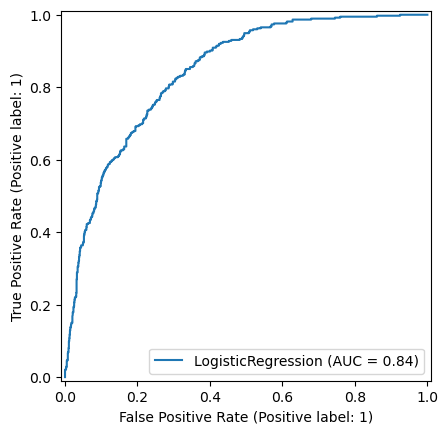

In [27]:
# ROC Curve 
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

## 9. Feature Importance 


In [28]:
import pandas as pd
import plotly.express as px

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

fig = px.bar(
    feature_importance,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Top 15 Important Features'
)

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

### Conclusion

- Dataset: IBM Telco Customer Churn
- Best Model: Logistic Regression
- ROC-AUC: 0.8427
- Major churn drivers:
  - Electronic check payment method
  - Streaming TV and streaming movie services
  - Senior citizen customers
  - Higher monthly charges

### Factors Reducing Churn
- Two-year contracts
- Online security services
- Online backup services
- Longer customer tenure

### Recommendations
- Encourage customers to switch to long-term contracts.
- Promote online security and backup services.
- Investigate the high churn rate among electronic check users.
- Launch targeted retention campaigns for senior citizens and high-risk customers.

## 10. Saved the Model

## 11. Churn Probability Prediction

Using `predict_proba()` to get a **probability score** per customer — not just a binary Yes/No.  


In [34]:
#  Get probabilities
proba = best_model.predict_proba(X_test)[:, 1]   # probability of Churn = 1
preds = best_model.predict(X_test)

# Build output table for sample customers
sample = X_test.iloc[:15].copy()
sample['Predicted_Churn']       = preds[:15]
sample['Churn_Probability_Pct'] = (proba[:15] * 100).round(1)
sample['Churn_Label']           = sample['Predicted_Churn'].map({1:'Churn', 0:'No Churn'})

display(
    sample[['tenure', 'MonthlyCharges', 'TotalCharges',
                   'Churn_Label', 'Churn_Probability_Pct']]
    .sort_values('Churn_Probability_Pct', ascending=False)
    .style.background_gradient(subset='Churn_Probability_Pct', cmap='RdYlGn_r')
)

,tenure,MonthlyCharges,TotalCharges,Churn_Label,Churn_Probability_Pct
3524,11,84.800000,906.850000,Churn,69.000000
2280,8,100.150000,908.550000,Churn,68.500000
5748,21,99.850000,1992.550000,Churn,60.400000
3568,21,99.150000,1956.400000,No Churn,43.500000
1639,17,45.050000,770.600000,No Churn,40.200000
4460,18,78.200000,1468.750000,No Churn,39.300000
2079,70,106.050000,7554.050000,No Churn,27.300000
2976,19,24.100000,439.200000,No Churn,12.900000
5283,19,48.800000,953.650000,No Churn,12.700000
667,49,30.200000,1453.100000,No Churn,12.500000


## 12. Risk Segmentation

We segment all test customers into three risk tiers based on their churn probability: 

Low Risk | < 30% | No immediate action needed

Medium Risk | 30% – 70% | Proactive engagement (email campaign, check-in)

High Risk | > 70% | Urgent: personal outreach, retention offer 



In [35]:

risk_df = X_test.copy()
risk_df['Churn_Probability'] = best_model.predict_proba(X_test)[:, 1]
risk_df['Actual_Churn']      = y_test.values

# Convert to percentage
risk_df['Churn_Probability (%)'] = (
    risk_df['Churn_Probability'] * 100
).round(1)

# Risk Segmentation Function
def risk_segment(prob):
    if prob < 0.3:   return 'Low Risk'
    elif prob < 0.7: return 'Medium Risk'
    else:        return 'High Risk'

# Assign risk categories
risk_df['Risk_Segment'] = risk_df['Churn_Probability'].apply(risk_segment)

# Display few rows
print("Sample Predictions:")
display(
    risk_df[['Churn_Probability (%)', 'Risk_Segment']].iloc[:10]
)


Sample Predictions:


,Churn_Probability (%),Risk_Segment
437,4.8,Low Risk
2280,68.5,Medium Risk
2235,6.3,Low Risk
4460,39.3,Medium Risk
3761,2.2,Low Risk
5748,60.4,Medium Risk
3568,43.5,Medium Risk
2976,12.9,Low Risk
5928,0.3,Low Risk
1639,40.2,Medium Risk


In [36]:

print("Risk Segment Distribution:")
display(risk_df['Risk_Segment'].value_counts())


# Top High-Risk Customers

print("Top 10 Customers Most Likely to Churn:")
display(
    risk_df.sort_values(by='Churn_Probability',ascending=False).head(10))


Risk Segment Distribution:


Risk_Segment
Low Risk       865
Medium Risk    449
High Risk       95
Name: count, dtype: int64

Top 10 Customers Most Likely to Churn:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Probability,Actual_Churn,Churn_Probability (%),Risk_Segment
3380,1,1,1,0,1,1,1,95.10,95.10,False,...,True,False,False,False,True,False,0.854732,1,85.5,High Risk
6866,1,0,0,0,1,1,1,95.45,95.45,False,...,True,False,False,False,True,False,0.831627,1,83.2,High Risk
2631,1,1,1,0,7,1,1,99.25,665.45,False,...,True,False,False,False,True,False,0.827242,1,82.7,High Risk
6365,1,1,1,0,7,1,1,101.95,700.85,False,...,True,False,False,False,True,False,0.826065,1,82.6,High Risk
3727,0,0,0,0,3,1,1,96.60,291.90,False,...,True,False,False,False,True,False,0.819595,1,82.0,High Risk
4585,0,1,0,0,1,1,1,85.05,85.05,False,...,True,False,False,False,True,False,0.819174,1,81.9,High Risk
2797,1,0,0,0,3,1,1,100.95,329.95,False,...,True,False,False,False,True,False,0.818834,1,81.9,High Risk
3346,0,1,0,0,2,1,1,84.05,186.05,False,...,True,False,False,False,True,False,0.816098,0,81.6,High Risk
6894,1,1,1,0,3,1,1,105.90,334.65,False,...,True,False,False,False,True,False,0.815817,1,81.6,High Risk
4039,1,0,0,0,7,1,1,94.10,701.30,False,...,True,False,False,False,True,False,0.808986,0,80.9,High Risk


In [37]:

# Risk Segment Summary

segment_summary = risk_df.groupby('Risk_Segment')['Churn_Probability (%)'].agg(['count', 'mean']).round(1)

segment_summary.columns = [
    'Number_of_Customers',
    'Average_Churn_Probability'
]

print("Risk Segment Summary:")
display(segment_summary)


Risk Segment Summary:


,Number_of_Customers,Average_Churn_Probability
Risk_Segment,,
High Risk,95,74.9
Low Risk,865,9.4
Medium Risk,449,50.1


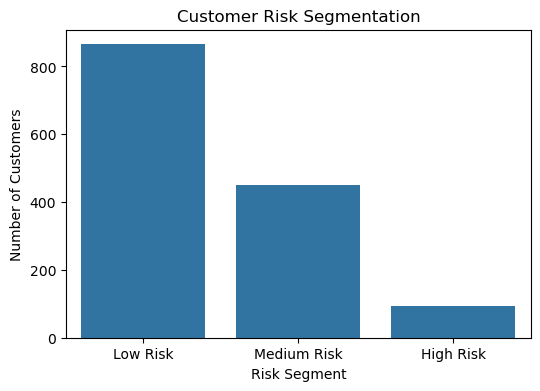

In [38]:

# Visualization

plt.figure(figsize=(6, 4))
sns.countplot(
    data=risk_df,
    x='Risk_Segment',
    order=['Low Risk', 'Medium Risk', 'High Risk']
)

plt.title('Customer Risk Segmentation')
plt.xlabel('Risk Segment')
plt.ylabel('Number of Customers')
plt.show()


## 13. Business Recommendations

### 🔴 Immediate Actions

#### 1. Target Month-to-Month Customers
Month-to-month customers show the highest churn rate. Encourage them to switch to longer-term contracts through discounts, loyalty rewards, or special offers.

#### 2. Use the Churn Model for Proactive Retention
Deploy the churn prediction model to identify high-risk customers and contact them before they decide to leave.

#### 3. Improve Early Customer Retention
Most churn occurs during the first year. Strengthen onboarding and customer engagement during the initial months to improve retention.


### 🟡 Medium-Term Initiatives

#### 4. Enhance Value for Fibre Optic Customers
Fibre optic customers have a relatively high churn rate despite paying higher fees. Improving service quality and customer support may help reduce churn.

#### 5. Promote Additional Support Services
Customers without Tech Support or Online Security are more likely to churn. Offering bundled support packages could improve customer retention.



### 🟢 Long-Term Strategies

#### 6. Reward Loyal Customers
Long-tenure customers are less likely to churn. Introduce loyalty rewards, exclusive benefits, or retention programmes to encourage long-term customer relationships.


### Priority Actions

1. Target month-to-month customers.
2. Implement churn-risk monitoring.
3. Improve onboarding for new customers.

These initiatives are expected to have the greatest impact on reducing customer churn.


## 14. Conclusion

### Key Findings


| Finding | Detail |
|---------|--------|
| **Churn Rate** | ~26.5% — above industry average |
| **Monthly Revenue at Risk** | ~$139,130/month |
| **#1 Churn Driver** | Contract type (Month-to-Month = 43% churn rate) |
| **#2 Driver** | Customer tenure — most churners leave in Year 1 |
| **#3 Driver** | Monthly charges — high-paying customers with low tenure are highest risk |


### Model Performance

Several machine learning models were evaluated, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and LightGBM.

Logistic Regression achieved the best balance of Precision, Recall, F1-Score, and ROC-AUC, making it suitable for identifying customers at risk of churn.

### Model Results Summary


| Model | Accuracy | Precision | Recall | F1 Score | ROC AUC |
|--------|----------|-----------|--------|----------|---------|
| Logistic Regression | 80.62% | 65.73% | 56.42% | 60.72% | 84.27% |
| Gradient Boosting | 79.91% | 65.64% | 51.07% | 57.44% | 84.23% |
| LightGBM | 79.42% | 63.12% | 54.01% | 58.21% | 83.62% |
| Random Forest | 78.42% | 62.07% | 48.13% | 54.22% | 82.32% |
| XGBoost | 77.22% | 58.31% | 49.73% | 53.68% | 82.24% |
| Decision Tree | 73.17% | 49.44% | 47.59% | 48.50% | 64.95% |


### Business Impact

A targeted retention programme using this model's predictions could realistically:
- Reduce churn by **15–20%** among High Risk customers
- Recover **$20,000–$28,000/month** in otherwise-lost revenue
- Improve average customer lifetime value by extending average tenure from 18 to 24+ months

*Customer Churn Prediction Project | IBM Telco Customer Churn Dataset | Python, Pandas, Scikit-Learn, Matplotlib, Seaborn*
